In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error


In [2]:
# Load data
train = pd.read_csv("Data/Train.csv")
test = pd.read_csv("Data/Test.csv")
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [3]:
train.describe()

,year,household_size,age_of_respondent
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


In [7]:
train.shape

(23524, 13)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [5]:
# Check for missing values
print('missing values:', train.isnull().sum())

missing values: country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


In [6]:
#Checking for nulls and duplicates
print(f"Number of Nulls: {train.isnull().sum().sum()}")
print(f"Number of Duplicates: {train.duplicated().sum()}")

#train = train.drop_duplicates()
#print(f"Number of Duplicates after dropping: {train.duplicated().sum()}")

Number of Nulls: 0
Number of Duplicates: 0


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

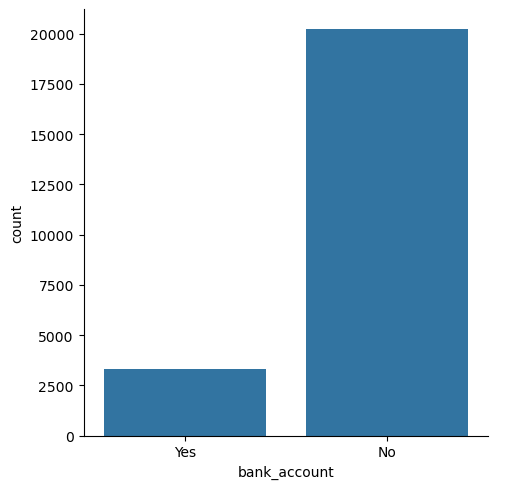

In [8]:
# Explore Target distribution
sns.catplot(x="bank_account", kind="count", data=train)

In [9]:
# Encode Target Variable
le_target = LabelEncoder()
train["bank_account"] = le_target.fit_transform(train["bank_account"])

In [10]:
# Separate Features & Target
y = train["bank_account"]
X = train.drop("bank_account", axis=1)

In [11]:
# Save test IDs for submission
test_ids = test["uniqueid"]

In [12]:
# Preprocessing Function
def preprocess(data):

    data = data.copy()

    # Drop ID column
    data = data.drop("uniqueid", axis=1)

    # One-hot encode categorical variables
    categorical_cols = [
        "relationship_with_head",
        "marital_status",
        "education_level",
        "job_type",
        "country"
    ]

    data = pd.get_dummies(data, columns=categorical_cols)

    # Label encode binary columns
    le = LabelEncoder()
    data["location_type"] = le.fit_transform(data["location_type"])
    data["cellphone_access"] = le.fit_transform(data["cellphone_access"])
    data["gender_of_respondent"] = le.fit_transform(data["gender_of_respondent"])

    return data


In [13]:
# Apply preprocessing
X = preprocess(X)
test = preprocess(test)

In [14]:
# Align train and test columns
X, test = X.align(test, join="left", axis=1, fill_value=0)

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
# Feature Scaling
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test)

In [17]:
# Train / Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y,
    test_size=0.1,
    stratify=y,
    random_state=42
)


In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
# Train Model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [22]:
from sklearn.metrics import accuracy_score

In [23]:
# Validation Prediction
val_preds = model.predict(X_val)

accuracy = accuracy_score(y_val, val_preds)
print("Validation Accuracy:", accuracy)


Validation Accuracy: 0.8601784955376116


In [24]:
# Train on full data
model.fit(X_scaled, y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [25]:
# Predict Test Data
test_preds = model.predict(test_scaled)

In [26]:
# Convert back to original labels
test_preds = le_target.inverse_transform(test_preds)

In [27]:
# Create Submission File
submission = pd.DataFrame({
    "uniqueid": test_ids,
    "bank_account": test_preds
})

submission.to_csv("submission.csv", index=False)

print("Submission file created!")

Submission file created!
